In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency
from statsmodels.stats.weightstats import ztest
import sys
import os

sys.path.append("..")

In [2]:
df = pd.read_csv("../data/insurance_data_clean.csv")

df.head()

C:\Users\YOGA 9I\AppData\Local\Temp\ipykernel_26852\1881377468.py:1: DtypeWarning: Columns (0: CapitalOutstanding) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/insurance_data_clean.csv")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [3]:
df["ClaimOccurred"] = (df["TotalClaims"] > 0).astype(int)

df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

df["ClaimSeverity"] = np.where(
    df["TotalClaims"] > 0,
    df["TotalClaims"],
    np.nan
)

In [15]:
from src.hypothesis_tests import run_ttest, run_ztest, run_chi_square, decision

In [16]:
province_df = df[df["Province"].isin(["Gauteng", "Northern Cape"])]

table = pd.crosstab(
    province_df["Province"],
    province_df["ClaimOccurred"]
)

stat1, p1 = run_chi_square(table)
d1 = decision(p1)

print(p1)
print(d1)

0.00534907280471951
Reject H₀


In [17]:
zip_df = df[df["PostalCode"].isin([2000, 8001])]

table = pd.crosstab(
    zip_df["PostalCode"],
    df.loc[zip_df.index, "ClaimOccurred"]
)

stat2, p2 = run_chi_square(table)
d2 = decision(p2)

print(p2)
print(d2)

0.6592711885830258
Fail to Reject H₀


In [18]:
zip1 = df[df["PostalCode"] == 2000]["Margin"]
zip2 = df[df["PostalCode"] == 8001]["Margin"]

stat3, p3 = run_ttest(zip1, zip2)
d3 = decision(p3)

print(p3)
print(d3)

0.9670204139985747
Fail to Reject H₀


In [19]:
male = df[df["Gender"] == "Male"]["ClaimSeverity"].dropna()
female = df[df["Gender"] == "Female"]["ClaimSeverity"].dropna()

stat4, p4 = run_ztest(male, female)
d4 = decision(p4)

print(p4)
print(d4)

0.6751676886605728
Fail to Reject H₀


In [20]:
results = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Zip Code Risk Difference",
        "Zip Code Margin Difference",
        "Gender Risk Difference"
    ],
    "Test": [
        "Chi-square",
        "Chi-square",
        "T-test",
        "Z-test"
    ],
    "P-value": [
        p1, p2, p3, p4
    ],
    "Decision": [
        d1, d2, d3, d4
    ]
})

results

,Hypothesis,Test,P-value,Decision
0,Province Risk Difference,Chi-square,0.005349,Reject H₀
1,Zip Code Risk Difference,Chi-square,0.659271,Fail to Reject H₀
2,Zip Code Margin Difference,T-test,0.967020,Fail to Reject H₀
3,Gender Risk Difference,Z-test,0.675168,Fail to Reject H₀


# Hypothesis Testing Results

## 1. Province Risk Difference
- **Test:** Chi-square  
- **P-value:** 0.005349  
- **Decision:** Reject H₀  

**Interpretation:**  
There is a statistically significant difference in claim frequency between provinces. This suggests province should be considered in regional pricing strategies.

---

## 2. Zip Code Risk Difference
- **Test:** Chi-square  
- **P-value:** 0.659271  
- **Decision:** Fail to Reject H₀  

**Interpretation:**  
No significant difference was found in claim frequency between the selected zip codes.

---

## 3. Zip Code Margin Difference
- **Test:** T-test  
- **P-value:** 0.967020  
- **Decision:** Fail to Reject H₀  

**Interpretation:**  
There is no significant difference in margin across the selected zip codes.

---

## 4. Gender Risk Difference
- **Test:** Z-test  
- **P-value:** 0.675168  
- **Decision:** Fail to Reject H₀  

**Interpretation:**  
Claim severity does not significantly differ between male and female policyholders.

---

# Business Conclusion

The results show that **province is the only statistically significant factor affecting insurance risk**.

This suggests ACIS should prioritize **province-based pricing adjustments**, while zip code and gender currently provide limited value for pricing segmentation.

---


<Axes: xlabel='Province'>

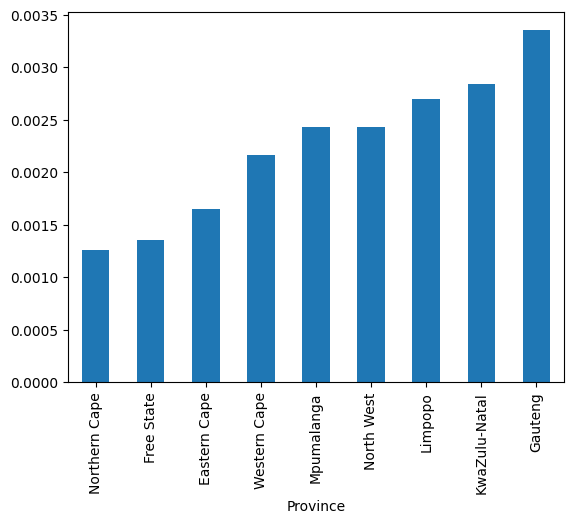

In [21]:
df.groupby("Province")["ClaimOccurred"].mean().sort_values().plot(kind="bar")

<Axes: xlabel='PostalCode'>

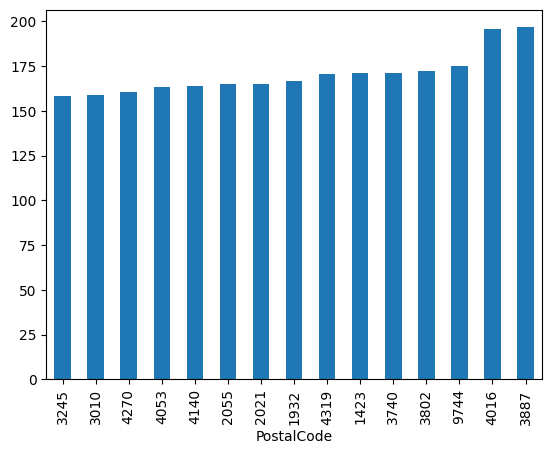

In [22]:
df.groupby("PostalCode")["Margin"].mean().sort_values().tail(15).plot(kind="bar")

<Axes: title={'center': 'ClaimSeverity'}, xlabel='Gender'>

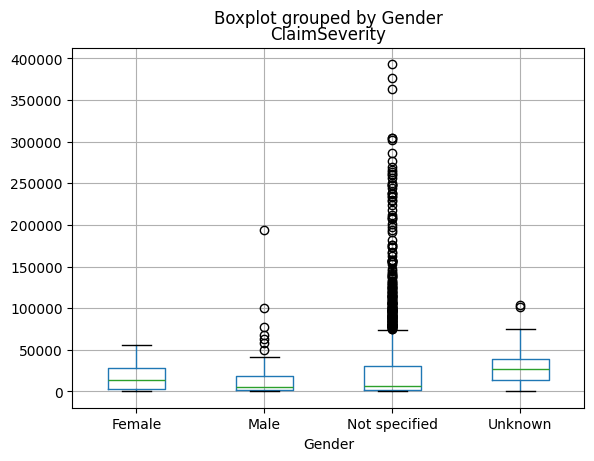

In [23]:
df.boxplot(column="ClaimSeverity", by="Gender")

# Hypothesis Testing Results and Business Interpretation

## 1. Province Risk Difference

**Test Used:** Chi-square Test  
**P-value:** 0.005349  
**Decision:** Reject H₀  

### Interpretation
Since the p-value is less than the significance threshold of 0.05, the null hypothesis is rejected. This indicates a statistically significant difference in claim frequency between provinces.

### Business Insight
Province is a significant predictor of insurance risk. This suggests that ACIS should consider implementing province-level risk segmentation and regional pricing adjustments to improve premium accuracy.

---

## 2. Zip Code Risk Difference

**Test Used:** Chi-square Test  
**P-value:** 0.659271  
**Decision:** Fail to Reject H₀  

### Interpretation
Since the p-value is greater than 0.05, there is insufficient statistical evidence to conclude that claim frequency differs significantly between the tested zip codes.

### Business Insight
Zip code alone does not appear to significantly explain variations in claim occurrence. It should not currently be prioritized as a major pricing factor.

---

## 3. Zip Code Margin Difference

**Test Used:** Independent T-test  
**P-value:** 0.967020  
**Decision:** Fail to Reject H₀  

### Interpretation
Since the p-value is much greater than 0.05, there is no statistically significant difference in profit margins between the selected zip codes.

### Business Insight
The profitability across these zip codes appears consistent. This suggests that pricing adjustments based solely on zip code are unlikely to improve financial performance.

---

## 4. Gender Risk Difference

**Test Used:** Z-test  
**P-value:** 0.675168  
**Decision:** Fail to Reject H₀  

### Interpretation
Since the p-value is greater than 0.05, there is insufficient evidence to conclude that claim severity differs significantly between male and female policyholders.

### Business Insight
Gender does not significantly affect claim severity in this dataset. Therefore, it should not be considered a strong variable for premium differentiation.

---

# Overall Business Conclusion

The hypothesis testing results show that:

- **Province** is the only statistically significant variable affecting insurance risk
- **Zip code risk differences are not statistically significant**
- **Zip code margin differences are not statistically significant**
- **Gender does not significantly affect claim severity**

These findings suggest that ACIS should prioritize **province-based risk segmentation** when designing pricing strategies.

---

# Statistical Testing KPIs Evaluated

The following key performance indicators (KPIs) were used in this analysis:

- **Claim Frequency**
- **Claim Severity**
- **Margin (TotalPremium - TotalClaims)**

These KPIs provide measurable indicators for evaluating insurance risk and pricing effectiveness.

---